# Music Health Analysis — Simplified Methodology + Predictive Models

This notebook cleans the event-level show dataset, joins it to sleep/health data, creates recovery windows around each event, engineers interpretable metrics, builds an intensity score, and fits lightweight predictive models.

Because this is a small personal dataset, the modeling section is exploratory. The goal is not to claim causal effects. The goal is to learn patterns, generate hypotheses, and make future event planning more data-informed.

## 1. Imports and display settings

We use pandas/numpy for data prep, matplotlib for basic visuals, and scikit-learn/statsmodels for modeling.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report
from statsmodels.formula.api import ols

import statsmodels.formula.api as smf

pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 100)

## 2. Load the show/event dataset

Methodology:
- Each row represents one calendar date.
- A date is flagged as a show/event when `event_name` is populated.
- Non-modeling narrative fields are dropped here to keep the analysis clean.
- Column names are standardized to lowercase snake case so the rest of the notebook is easier to read.

In [43]:
show_raw = pd.read_csv("show_dataset_0426.csv")

show_raw["Date"] = pd.to_datetime(show_raw["Date"])

show_raw = show_raw.drop(columns=[
    "Biggest Surprise",
    "Challenged Assumptions",
    "Field Notes",
    "What Felt Off",
    "Connection Outcome",
    "Connection Type",
    "fun"
], errors="ignore")

show_raw["show"] = show_raw["Event Name"].notna().astype(int)

show_raw.columns = (
    show_raw.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)

show_raw.head()

,event_name,crowd_size,date,density,embodiment,energy_before,event_type,genre,interactions_(others),interactions_(you),mood_next_day,notable_connection,outfit_expression_level,solo_vs._group,fun_intensity,venu_name,visual_intensity,show
0,Get Lucky,Medium,2026-03-13,Packed,10,8,Festival,"Drum & Bass, Dubstep",NaN,2.00,7,Yes,10,Group,8,Saltair,7,1
1,Zingara & Level Up,Large,2026-02-06,Packed,8,10,Venue,Experimental Bass,NaN,1.00,9,No,7,Group,10,The Complex,10,1
2,Alison Wonderland,Large,2026-02-28,Packed,10,8,Warehouse,"Future Bass, Trap",2.00,NaN,8,No,5,Group,3,BOXPAC,6,1
3,Kaivon,Small,2026-03-07,Moderate,10,9,Venue,Future Bass,NaN,3.00,6,Yes,5,Duo,10,The Complex,7,1
4,Get Freaky,Massive,2025-10-24,Packed,10,10,Festival,Mixed,2.00,NaN,8,Yes,9,Duo,8,SLC Fairgrounds,8,1


## 3. Load and combine sleep files

Methodology:
- Garmin sleep exports are stored as multiple CSV files.
- We concatenate them into one table.
- Dates are converted to datetime.
- Duplicate dates are removed so each date has one sleep record.

In [44]:
sleep_files = [
    f for f in os.listdir()
    if f.lower().startswith("sleep") and f.lower().endswith(".csv")
]

sleep_files = sorted(sleep_files)

sleep_frames = []

for file in sleep_files:
    print(f"Loading: {file}")
    
    temp = pd.read_csv(file)

    # clean columns early
    temp.columns = (
        temp.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.lower()
    )

    # handle Garmin naming chaos
    if "sleep_score_4_weeks" in temp.columns:
        temp = temp.rename(columns={"sleep_score_4_weeks": "date"})
    elif "date" not in temp.columns:
        raise ValueError(f"No date column found in {file}")

    temp["date"] = pd.to_datetime(temp["date"], errors="coerce")

    sleep_frames.append(temp)

sleep = pd.concat(sleep_frames, ignore_index=True)

sleep = sleep.drop_duplicates(subset=["date"], keep="first")
sleep = sleep.sort_values("date").reset_index(drop=True)

sleep.head()

Loading: Sleep Aug 18 - Sep 14.csv
Loading: Sleep Jun 23 - July 20.csv
Loading: Sleep Sep 15 - Oct 12.csv
Loading: Sleep apr 24 - may 21.csv
Loading: Sleep dec 4 - dec 31.csv
Loading: Sleep feb 26 - mar 25.csv
Loading: Sleep jan 1 - jan 28.csv
Loading: Sleep jan 29 - feb 25.csv
Loading: Sleep jul 17 - aug18.csv
Loading: Sleep mar 26 - apr22.csv
Loading: Sleep may 26 - jin 22.csv
Loading: Sleep nov 6 - dec 3.csv
Loading: Sleep oct 9 - nov 5.csv
Loading: sleep apr 28 - may 25.csv


,date,score,resting_heart_rate,body_battery,pulse_ox,respiration,skin_temp_change,hrv_status,quality,duration,sleep_need,bedtime,wake_time
0,2025-04-24,83,53,69,--,14,+0.1°,39,Good,7h 42min,8h 0min,11:02 PM,7:01 AM
1,2025-04-25,84,52,60,--,14,-0.1°,40,Good,7h 27min,8h 0min,12:00 AM,7:37 AM
2,2025-04-26,78,56,42,--,15,+0.1°,42,Fair,7h 27min,8h 0min,11:23 PM,7:02 AM
3,2025-04-27,80,55,59,--,14,-0.4°,42,Good,6h 50min,8h 0min,11:55 PM,6:55 AM
4,2025-04-28,84,54,52,--,15,0°,42,Good,7h 31min,8h 0min,11:37 PM,7:09 AM


In [45]:
sleep["date"].min(), sleep["date"].max(), sleep["date"].nunique()

(Timestamp('2025-04-24 00:00:00'), Timestamp('2026-04-22 00:00:00'), 360)

## 4. Merge events with same-day sleep data

This creates one daily table with both event fields and health/sleep fields.

In [46]:
daily = pd.merge(show_raw, sleep, on="date", how="outer")

daily = daily.sort_values("date").reset_index(drop=True)

daily.head()

,event_name,crowd_size,date,density,embodiment,energy_before,event_type,genre,interactions_(others),interactions_(you),mood_next_day,notable_connection,outfit_expression_level,solo_vs._group,fun_intensity,venu_name,visual_intensity,show,score,resting_heart_rate,body_battery,pulse_ox,respiration,skin_temp_change,hrv_status,quality,duration,sleep_need,bedtime,wake_time
0,NaN,NaN,2025-04-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83,53,69,--,14,+0.1°,39,Good,7h 42min,8h 0min,11:02 PM,7:01 AM
1,NaN,NaN,2025-04-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84,52,60,--,14,-0.1°,40,Good,7h 27min,8h 0min,12:00 AM,7:37 AM
2,NaN,NaN,2025-04-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78,56,42,--,15,+0.1°,42,Fair,7h 27min,8h 0min,11:23 PM,7:02 AM
3,NaN,NaN,2025-04-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80,55,59,--,14,-0.4°,42,Good,6h 50min,8h 0min,11:55 PM,6:55 AM
4,NaN,NaN,2025-04-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84,54,52,--,15,0°,42,Good,7h 31min,8h 0min,11:37 PM,7:09 AM


## 5. Create event-centered recovery windows

For every show date, this creates sleep/health values for:
- `-1`: the day before the event
- `+0`: the event day
- `+1`: the day after
- `+2`: two days after
- `+3`: three days after

These offset columns let us compare baseline vs. post-event recovery.

In [47]:
show_days = daily.loc[daily["show"] == 1, ["date"]].copy()

offsets = range(-1, 4)

show_window = pd.concat(
    [
        show_days.assign(
            show_date=show_days["date"],
            relative_day=offset,
            date=show_days["date"] + pd.to_timedelta(offset, unit="D")
        )
        for offset in offsets
    ],
    ignore_index=True
)

health_cols = [
    "score",
    "resting_heart_rate",
    "hrv_status",
    "body_battery",
    "respiration",
    "pulse_ox",
    "skin_temp_change",
    "bedtime",
    "wake_time"
]

available_health_cols = [col for col in health_cols if col in daily.columns]

window_long = pd.merge(
    show_window,
    daily[["date"] + available_health_cols],
    on="date",
    how="left"
)

wide = window_long.pivot_table(
    index="show_date",
    columns="relative_day",
    values=available_health_cols,
    aggfunc="first"
)

wide.columns = [f"{metric}_{offset:+d}" for metric, offset in wide.columns]
wide = wide.reset_index().rename(columns={"show_date": "date"})

wide.head()

,date,bedtime_-1,bedtime_+0,bedtime_+1,bedtime_+2,bedtime_+3,body_battery_-1,body_battery_+0,body_battery_+1,body_battery_+2,body_battery_+3,hrv_status_-1,hrv_status_+0,hrv_status_+1,hrv_status_+2,hrv_status_+3,pulse_ox_-1,pulse_ox_+0,pulse_ox_+1,pulse_ox_+2,pulse_ox_+3,respiration_-1,respiration_+0,respiration_+1,respiration_+2,respiration_+3,resting_heart_rate_-1,resting_heart_rate_+0,resting_heart_rate_+1,resting_heart_rate_+2,resting_heart_rate_+3,score_-1,score_+0,score_+1,score_+2,score_+3,skin_temp_change_-1,skin_temp_change_+0,skin_temp_change_+1,skin_temp_change_+2,skin_temp_change_+3,wake_time_-1,wake_time_+0,wake_time_+1,wake_time_+2,wake_time_+3
0,2025-05-16,11:55 PM,11:31 PM,1:40 AM,12:52 AM,11:45 PM,53,52,25,78,67,40,39,36,37,37,--,--,--,--,--,15,14,16,13,14,56,52,59,51,52,76,74,51,79,87,-0.1°,+0.6°,+0.9°,+0.6°,+0.8°,7:10 AM,7:30 AM,7:33 AM,7:45 AM,8:03 AM
1,2025-08-08,12:29 AM,12:48 AM,--,12:40 AM,10:43 PM,66,35,--,12,69,32,32,--,32,33,--,--,--,--,--,15.54,15.71,--,17.76,15.45,56,58,--,61,56,82,83,--,51,86,+0.6°,0°,--,+0.6°,-0.3°,7:57 AM,8:41 AM,--,7:56 AM,6:35 AM
2,2025-10-24,11:34 PM,11:47 PM,4:02 AM,12:19 AM,11:25 PM,62,63,12,70,66,36,36,35,34,34,--,--,--,--,--,15.92,14.96,17.96,15.94,15.16,56,55,59,59,56,87,91,34,88,90,-0.5°,+0.1°,+0.9°,-0.2°,+0.4°,8:08 AM,7:46 AM,9:04 AM,8:57 AM,8:05 AM
3,2025-11-14,12:30 AM,12:19 AM,9:59 AM,--,10:34 PM,41,49,14,--,63,36,36,33,--,33,--,--,--,--,--,14.96,15.6,18.42,--,15.17,59,59,61,--,54,76,75,47,--,95,+0.2°,-0.3°,+1.3°,--,+0.1°,8:14 AM,7:54 AM,1:57 PM,--,6:16 AM
4,2025-11-29,12:14 AM,12:20 AM,2:53 AM,11:20 PM,--,57,54,52,56,--,32,32,34,34,--,--,--,--,--,--,15.74,15.57,15.29,14.83,--,60,59,59,53,--,83,82,83,97,--,-0.5°,-0.8°,-1.1°,-0.4°,--,9:04 AM,9:27 AM,10:19 AM,8:08 AM,--


## 6. Create the modeling dataset

Methodology:
- Keep only actual event rows.
- Join in the event-centered recovery window.
- Drop high-noise or duplicate fields.
- Replace placeholder values with missing values.

In [48]:
show_with_window = pd.merge(daily, wide, on="date", how="left")

show_df = show_with_window.loc[show_with_window["show"] == 1].copy()

show_df = show_df.drop(columns=[
    "interactions_(others)",
    "interactions_(you)",
    "show",
    "score",
    "bedtime",
    "wake_time",
    "body_battery",
    "pulse_ox",
    "respiration",
    "skin_temp_change",
    "notable_connection",
    "hrv_status",
    "quality",
    "duration",
    "sleep_need",
    "solo_vs._group",
    "bedtime_dt",
    "bedtime_hour",
    "bedtime_hour_adj"
], errors="ignore")

show_df = show_df.replace("--", pd.NA)

show_df.head()

,event_name,crowd_size,date,density,embodiment,energy_before,event_type,genre,mood_next_day,outfit_expression_level,fun_intensity,venu_name,visual_intensity,resting_heart_rate,bedtime_-1,bedtime_+0,bedtime_+1,bedtime_+2,bedtime_+3,body_battery_-1,body_battery_+0,body_battery_+1,body_battery_+2,body_battery_+3,hrv_status_-1,hrv_status_+0,hrv_status_+1,hrv_status_+2,hrv_status_+3,pulse_ox_-1,pulse_ox_+0,pulse_ox_+1,pulse_ox_+2,pulse_ox_+3,respiration_-1,respiration_+0,respiration_+1,respiration_+2,respiration_+3,resting_heart_rate_-1,resting_heart_rate_+0,resting_heart_rate_+1,resting_heart_rate_+2,resting_heart_rate_+3,score_-1,score_+0,score_+1,score_+2,score_+3,skin_temp_change_-1,skin_temp_change_+0,skin_temp_change_+1,skin_temp_change_+2,skin_temp_change_+3,wake_time_-1,wake_time_+0,wake_time_+1,wake_time_+2,wake_time_+3
22,Maesic,Small,2025-05-16,Spacious,4.00,8.00,Warehouse,NaN,6.00,3.00,1.00,Ranger Soundcar,7.00,52,11:55 PM,11:31 PM,1:40 AM,12:52 AM,11:45 PM,53,52,25,78,67,40,39,36,37,37,<NA>,<NA>,<NA>,<NA>,<NA>,15,14,16,13,14,56,52,59,51,52,76,74,51,79,87,-0.1°,+0.6°,+0.9°,+0.6°,+0.8°,7:10 AM,7:30 AM,7:33 AM,7:45 AM,8:03 AM
106,Das Energi,Massive,2025-08-08,Moderate,10.00,10.00,Festival,Mixed,8.00,7.00,10.00,Saltair,10.00,58,12:29 AM,12:48 AM,<NA>,12:40 AM,10:43 PM,66,35,<NA>,12,69,32,32,<NA>,32,33,<NA>,<NA>,<NA>,<NA>,<NA>,15.54,15.71,<NA>,17.76,15.45,56,58,<NA>,61,56,82,83,<NA>,51,86,+0.6°,0°,<NA>,+0.6°,-0.3°,7:57 AM,8:41 AM,<NA>,7:56 AM,6:35 AM
179,Get Freaky,Massive,2025-10-24,Packed,10.00,10.00,Festival,Mixed,8.00,9.00,8.00,SLC Fairgrounds,8.00,55,11:34 PM,11:47 PM,4:02 AM,12:19 AM,11:25 PM,62,63,12,70,66,36,36,35,34,34,<NA>,<NA>,<NA>,<NA>,<NA>,15.92,14.96,17.96,15.94,15.16,56,55,59,59,56,87,91,34,88,90,-0.5°,+0.1°,+0.9°,-0.2°,+0.4°,8:08 AM,7:46 AM,9:04 AM,8:57 AM,8:05 AM
200,Lumanasi,Small,2025-11-14,Moderate,8.00,8.00,Venue,"Experimental Bass, Trance",8.00,4.00,8.00,Soundwell,6.00,59,12:30 AM,12:19 AM,9:59 AM,<NA>,10:34 PM,41,49,14,<NA>,63,36,36,33,<NA>,33,<NA>,<NA>,<NA>,<NA>,<NA>,14.96,15.6,18.42,<NA>,15.17,59,59,61,<NA>,54,76,75,47,<NA>,95,+0.2°,-0.3°,+1.3°,<NA>,+0.1°,8:14 AM,7:54 AM,1:57 PM,<NA>,6:16 AM
215,Maddy O’Neal,Small,2025-11-29,Moderate,7.00,7.00,Club,NaN,7.00,4.00,0.00,EVE SLC,5.00,59,12:14 AM,12:20 AM,2:53 AM,11:20 PM,<NA>,57,54,52,56,<NA>,32,32,34,34,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,15.74,15.57,15.29,14.83,<NA>,60,59,59,53,<NA>,83,82,83,97,<NA>,-0.5°,-0.8°,-1.1°,-0.4°,<NA>,9:04 AM,9:27 AM,10:19 AM,8:08 AM,<NA>


## 7. Build interpretable metrics

Metric definitions:
- `show_sleep_drop_from_baseline`: sleep score day after show minus sleep score day before show.
- `pre_show_drop`: event-day sleep score minus day-before sleep score.
- `prev_day_show`: whether another event happened the prior calendar day.
- `sleep_variability`: standard deviation of sleep score across baseline, +1, and +2.
- `efficiency`: embodiment plus sleep change. This rewards high embodiment and penalizes sleep disruption.
- `days_to_recover_sleep`: how many days it takes sleep score to return within 5 points of baseline.
- `days_to_recover_hrv`: how many days it takes HRV to return within 3 ms of baseline.
- `high_value_night`: 1 when embodiment is high and sleep recovery is fast.

In [49]:
numeric_exclusions = [
    "event_name", "date", "event_type", "genre", "crowd_size", "density",
    "bedtime_-1", "bedtime_+0", "bedtime_+1", "bedtime_+2", "bedtime_+3"
]

numeric_cols = [col for col in show_df.columns if col not in numeric_exclusions]

show_df[numeric_cols] = show_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

show_df["show_sleep_drop_from_baseline"] = show_df["score_+1"] - show_df["score_-1"]
show_df["pre_show_drop"] = show_df["score_+0"] - show_df["score_-1"]
show_df["prev_day_show"] = show_df["date"].diff().dt.days == 1

show_df["sleep_variability"] = show_df[["score_-1", "score_+1", "score_+2"]].std(axis=1)
show_df["efficiency"] = show_df["embodiment"] + show_df["show_sleep_drop_from_baseline"]

def days_to_recover(row, baseline_col, recovery_cols, tolerance):
    baseline = row[baseline_col]

    if pd.isna(baseline):
        return pd.NA

    for i, col in enumerate(recovery_cols):
        if pd.notna(row[col]) and row[col] >= baseline - tolerance:
            return i

    return len(recovery_cols)

show_df["days_to_recover_sleep"] = show_df.apply(
    lambda row: days_to_recover(
        row,
        baseline_col="score_-1",
        recovery_cols=["score_+1", "score_+2", "score_+3"],
        tolerance=5
    ),
    axis=1
)

show_df["days_to_recover_hrv"] = show_df.apply(
    lambda row: days_to_recover(
        row,
        baseline_col="hrv_status_-1",
        recovery_cols=["hrv_status_+1", "hrv_status_+2", "hrv_status_+3"],
        tolerance=3
    ),
    axis=1
)

show_df["high_value_night"] = (
    (show_df["embodiment"] >= 9) &
    (show_df["days_to_recover_sleep"] <= 1)
).astype(int)

show_df[[
    "event_name",
    "date",
    "embodiment",
    "score_-1",
    "score_+1",
    "show_sleep_drop_from_baseline",
    "days_to_recover_sleep",
    "days_to_recover_hrv",
    "high_value_night"
]].head()

,event_name,date,embodiment,score_-1,score_+1,show_sleep_drop_from_baseline,days_to_recover_sleep,days_to_recover_hrv,high_value_night
22,Maesic,2025-05-16,4.00,76,51.00,-25.00,1,1,0
106,Das Energi,2025-08-08,10.00,82,NaN,NaN,2,1,0
179,Get Freaky,2025-10-24,10.00,87,34.00,-53.00,1,0,1
200,Lumanasi,2025-11-14,8.00,76,47.00,-29.00,2,0,0
215,Maddy O’Neal,2025-11-29,7.00,83,83.00,0.00,0,0,0


## 8. Build the event intensity score

Methodology:
- Categorical features like crowd size and density are mapped onto numeric scales.
- Features are normalized to a 0–1 range.
- A weighted score is calculated and converted to a 0–100-ish scale.

Current weighting logic:
- fun intensity is the strongest component because it likely has the largest downstream recovery impact.
- Visual intensity and embodiment represent the subjective experience.
- Energy, outfit expression, crowd size, and density add context without dominating the score.

Note: The weights below add to 1.00, so the score remains interpretable on a 0–100 scale.

In [50]:
crowd_map = {
    "Small": 1,
    "Medium": 2,
    "Large": 3,
    "Massive": 4
}

density_map = {
    "Spacious": 1,
    "Comfortable": 2,
    "Moderate": 2,
    "Crowded": 3,
    "Packed": 4
}

show_df["crowd_size_score"] = show_df["crowd_size"].map(crowd_map)
show_df["density_score"] = show_df["density"].map(density_map)

intensity_features = [
    "visual_intensity",
    "fun_intensity",
    "embodiment",
    "energy_before",
    "outfit_expression_level",
    "crowd_size_score",
    "density_score"
]

weights = {
    "visual_intensity": 0.20,
    "fun_intensity": 0.30,
    "embodiment": 0.20,
    "energy_before": 0.10,
    "outfit_expression_level": 0.10,
    "crowd_size_score": 0.05,
    "density_score": 0.05
}

score_df = show_df.copy()

scaler = MinMaxScaler()
score_df[intensity_features] = scaler.fit_transform(score_df[intensity_features])

show_df["intensity_score"] = sum(
    score_df[col] * weight
    for col, weight in weights.items()
) * 100

show_df["intensity_score"] = show_df["intensity_score"].round(1)

def intensity_category(score):
    if pd.isna(score):
        return pd.NA
    elif score < 35:
        return "low"
    elif score < 65:
        return "moderate"
    elif score < 90:
        return "high"
    else:
        return "very high"

show_df["intensity_category"] = show_df["intensity_score"].apply(intensity_category)

show_df[[
    "event_name",
    "crowd_size",
    "density",
    "crowd_size_score",
    "density_score",
    "fun_intensity",
    "intensity_score",
    "intensity_category"
]].sort_values("intensity_score", ascending=False)

,event_name,crowd_size,density,crowd_size_score,density_score,fun_intensity,intensity_score,intensity_category
106,Das Energi,Massive,Moderate,4,2,10.00,92.40,very high
247,Decadence,Massive,Packed,4,4,10.00,90.50,very high
284,Zingara & Level Up,Large,Packed,3,4,10.00,87.40,high
179,Get Freaky,Massive,Packed,4,4,8.00,84.60,high
222,Mersiv,Large,Packed,3,4,8.00,72.00,high
319,Get Lucky,Medium,Packed,2,4,8.00,72.00,high
313,Kaivon,Small,Moderate,1,2,10.00,69.20,high
264,OG Nixin,Medium,Spacious,2,1,9.00,51.50,moderate
200,Lumanasi,Small,Moderate,1,2,8.00,47.80,moderate
306,Alison Wonderland,Large,Packed,3,4,3.00,47.50,moderate


## 9. Quick data quality checks

These checks catch unmapped categories or missing values that would cause scores or models to fail.

In [51]:
print("Unmapped crowd sizes:")
print(show_df.loc[show_df["crowd_size_score"].isna(), "crowd_size"].dropna().unique())

print("\nUnmapped density values:")
print(show_df.loc[show_df["density_score"].isna(), "density"].dropna().unique())

print("\nRows missing intensity score:")
display(show_df.loc[
    show_df["intensity_score"].isna(),
    ["event_name", "visual_intensity", "fun_intensity", "embodiment",
     "energy_before", "outfit_expression_level", "crowd_size", "density"]
])

Unmapped crowd sizes:
[]

Unmapped density values:
[]

Rows missing intensity score:


,event_name,visual_intensity,fun_intensity,embodiment,energy_before,outfit_expression_level,crowd_size,density


## 10. Exploratory summaries

These summaries are descriptive only. With a small dataset, use them to find patterns worth tracking—not to overclaim.

In [52]:
summary_cols = [
    "embodiment",
    "intensity_score",
    "score_+1",
    "show_sleep_drop_from_baseline",
    "hrv_status_+1",
    "days_to_recover_sleep",
    "high_value_night"
]

show_df[summary_cols].describe()

,embodiment,intensity_score,score_+1,show_sleep_drop_from_baseline,hrv_status_+1,days_to_recover_sleep,high_value_night
count,16.00,16.00,12.00,12.00,12.00,16.00,16.00
mean,8.44,54.24,51.83,-30.33,33.42,1.38,0.31
std,1.97,27.49,19.48,24.35,2.19,0.89,0.48
min,4.00,13.10,24.00,-74.00,30.00,0.00,0.00
25%,7.00,35.85,37.00,-48.50,32.50,1.00,0.00
50%,9.50,49.65,53.50,-27.00,33.50,1.00,0.00
75%,10.00,75.15,59.75,-17.25,35.25,2.00,1.00
max,10.00,92.40,83.00,10.00,36.00,3.00,1.00


In [53]:
show_df.groupby("event_type")[[
    "embodiment",
    "intensity_score",
    "score_+1",
    "show_sleep_drop_from_baseline",
    "days_to_recover_sleep",
    "high_value_night"
]].mean().sort_values("embodiment", ascending=False)

,embodiment,intensity_score,score_+1,show_sleep_drop_from_baseline,days_to_recover_sleep,high_value_night
event_type,,,,,,
Festival,10.00,84.88,29.00,-63.50,2.25,0.25
Warehouse,8.60,44.58,49.75,-31.50,1.20,0.60
Venue,8.25,60.45,47.67,-35.33,1.50,0.25
Other,7.00,19.40,83.00,10.00,0.00,0.00
Club,6.00,22.15,69.50,-7.50,0.50,0.00


## 11. Visualize intensity vs. recovery outcomes

These plots help show whether higher intensity is associated with sleep disruption, slower recovery, or higher embodiment.

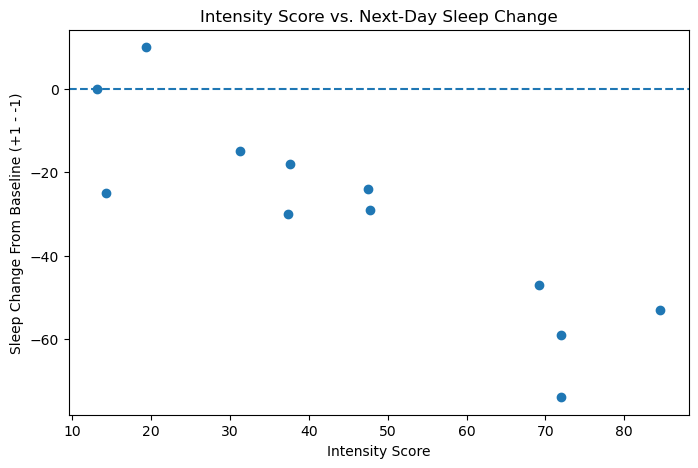

In [54]:
plot_df = show_df.dropna(subset=["intensity_score", "show_sleep_drop_from_baseline"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["intensity_score"], plot_df["show_sleep_drop_from_baseline"])
plt.axhline(0, linestyle="--")
plt.xlabel("Intensity Score")
plt.ylabel("Sleep Change From Baseline (+1 - -1)")
plt.title("Intensity Score vs. Next-Day Sleep Change")
plt.show()

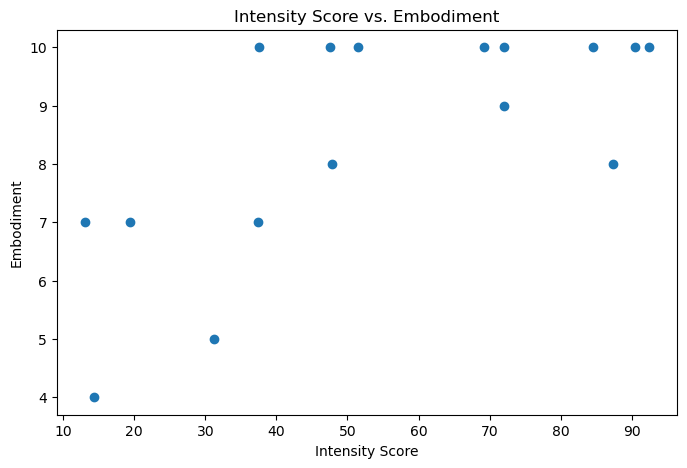

In [55]:
plot_df = show_df.dropna(subset=["intensity_score", "embodiment"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["intensity_score"], plot_df["embodiment"])
plt.xlabel("Intensity Score")
plt.ylabel("Embodiment")
plt.title("Intensity Score vs. Embodiment")
plt.show()

## 12. Prepare the modeling dataset

Predictive modeling targets:
- `show_sleep_drop_from_baseline`: continuous outcome.
- `days_to_recover_sleep`: continuous/ordinal recovery outcome.
- `high_value_night`: binary outcome.

Predictor features:
- Intensity score
- fun intensity
- Embodiment
- Energy before
- Outfit expression
- Crowd and density scores
- Previous-day show flag

Small-data warning:
This dataset is still tiny, so model outputs should be treated as exploratory signals.


In [68]:
model_features_raw = [
    "intensity_score",
    "fun_intensity",
    "score_-1",
    "score_+1",
    "embodiment",
    "energy_before",
    "outfit_expression_level",
    "crowd_size_score",
    "density_score",
    "prev_day_show"
]

model_targets = [
    "show_sleep_drop_from_baseline",
    "days_to_recover_sleep",
    "high_value_night"
]

model_df = show_df[["event_name", "date"] + model_features_raw + model_targets].copy()

model_df = model_df.rename(columns={
    "score_-1": "sleep_baseline",
    "score_+1": "sleep_plus1",
})

model_df["prev_day_show"] = model_df["prev_day_show"].astype(int)

model_features = [
    "intensity_score",
    "fun_intensity",
    "sleep_baseline",
    "sleep_plus1",
    "embodiment",
    "energy_before",
    "outfit_expression_level",
    "crowd_size_score",
    "density_score",
    "prev_day_show"
]

model_df = model_df.dropna(subset=model_features)

model_df

,event_name,date,intensity_score,fun_intensity,sleep_baseline,sleep_plus1,embodiment,energy_before,outfit_expression_level,crowd_size_score,density_score,prev_day_show,show_sleep_drop_from_baseline,days_to_recover_sleep,high_value_night
22,Maesic,2025-05-16,14.30,1.00,76,51.00,4.00,8.00,3.00,1,1,0,-25.00,1,0
179,Get Freaky,2025-10-24,84.60,8.00,87,34.00,10.00,10.00,9.00,4,4,0,-53.00,1,1
200,Lumanasi,2025-11-14,47.80,8.00,76,47.00,8.00,8.00,4.00,1,2,0,-29.00,2,0
215,Maddy O’Neal,2025-11-29,13.10,0.00,83,83.00,7.00,7.00,4.00,1,2,0,0.00,0,0
222,Mersiv,2025-12-06,72.00,8.00,85,26.00,9.00,9.00,6.00,3,4,0,-59.00,1,1
306,Alison Wonderland,2026-02-28,47.50,3.00,81,57.00,10.00,8.00,5.00,3,4,0,-24.00,1,1
313,Kaivon,2026-03-07,69.20,10.00,85,38.00,10.00,9.00,5.00,1,2,0,-47.00,1,1
319,Get Lucky,2026-03-13,72.00,8.00,98,24.00,10.00,8.00,10.00,2,4,0,-74.00,3,0
340,Nic Vans,2026-04-03,31.20,2.00,71,56.00,5.00,9.00,5.00,3,4,0,-15.00,1,0
341,Aquarium show,2026-04-04,19.40,0.00,73,83.00,7.00,7.00,4.00,1,1,1,10.00,0,0


## 13. Interpretable regression models

These simple models estimate directional relationships.

Model 1:
- Predicts sleep change from intensity score.

Model 2:
- Predicts days to recover sleep from intensity score.

Model 3:
- Predicts high-value night from intensity score using logistic regression.

In [69]:
sleep_model_df = model_df.dropna(subset=["show_sleep_drop_from_baseline"])

m_sleep = smf.ols(
    "show_sleep_drop_from_baseline ~ intensity_score",
    data=sleep_model_df
).fit()

m_sleep.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     show_sleep_drop_from_baseline   R-squared:                       0.762
Model:                                       OLS   Adj. R-squared:                  0.738
Method:                            Least Squares   F-statistic:                     32.06
Date:                           Sun, 26 Apr 2026   Prob (F-statistic):           0.000209
Time:                                   22:46:39   Log-Likelihood:                -46.199
No. Observations:                             12   AIC:                             96.40
Df Residuals:                                 10   BIC:                             97.37
Df Model:                                      1                                         
Covariance Type:                       nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           9.3481      7.877      1.187      0.263      -8.202      26.899
intensity_score    -0.8720      0.154     -5.662      0.000      -1.215      -0.529
==============================================================================
Omnibus:                        1.677   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.432   Jarque-Bera (JB):                0.979
Skew:                          -0.676   Prob(JB):                        0.613
Kurtosis:                       2.637   Cond. No.                         112.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [84]:
m_recovery = smf.ols(
    """
    days_to_recover_sleep ~ 
    intensity_score
    """,
    data=recovery_model_df
).fit()

m_recovery.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     days_to_recover_sleep   R-squared:                       0.405
Model:                               OLS   Adj. R-squared:                  0.362
Method:                    Least Squares   F-statistic:                     9.529
Date:                   Sun, 26 Apr 2026   Prob (F-statistic):            0.00804
Time:                           23:13:32   Log-Likelihood:                -16.080
No. Observations:                     16   AIC:                             36.16
Df Residuals:                         14   BIC:                             37.70
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.2635      0.401      0.657      0.522      -0.597       1.124
intensity_score     0.0205      0.007      3.087      0.008       0.006       0.035
==============================================================================
Omnibus:                        1.490   Durbin-Watson:                   2.798
Prob(Omnibus):                  0.475   Jarque-Bera (JB):                1.103
Skew:                           0.415   Prob(JB):                        0.576
Kurtosis:                       2.016   Cond. No.                         137.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [82]:
show_model = ols(
    """
    sleep_plus1 ~ 
    sleep_baseline +
    intensity_score
    """,
    data=model_df
).fit()

show_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sleep_plus1   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     12.08
Date:                Sun, 26 Apr 2026   Prob (F-statistic):            0.00283
Time:                        23:13:11   Log-Likelihood:                -44.314
No. Observations:                  12   AIC:                             94.63
Df Residuals:                       9   BIC:                             96.08
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          87.0021     43.189      2.014      0.075     -10.699     184.703
sleep_baseline     -0.0564      0.580     -0.097      0.925      -1.368       1.255
intensity_score    -0.6709      0.177     -3.786      0.004      -1.072      -0.270
==============================================================================
Omnibus:                        2.031   Durbin-Watson:                   2.099
Prob(Omnibus):                  0.362   Jarque-Bera (JB):                1.026
Skew:                          -0.710   Prob(JB):                        0.599
Kurtosis:                       2.813   Cond. No.                     1.27e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.27e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
binary_model_df = model_df.dropna(subset=["high_value_night"])

m_high_value = smf.logit(
    "high_value_night ~ intensity_score",
    data=binary_model_df
).fit(disp=False)

m_high_value.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       high_value_night   No. Observations:                   16
Model:                          Logit   Df Residuals:                       14
Method:                           MLE   Df Model:                            1
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                 0.06119
Time:                        22:19:50   Log-Likelihood:                -9.3293
converged:                       True   LL-Null:                       -9.9374
Covariance Type:            nonrobust   LLR p-value:                    0.2701
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -2.1292      1.449     -1.470      0.142      -4.969       0.710
intensity_score     0.0234      0.022      1.056      0.291      -0.020       0.067
===================================================================================
"""

## 14. Predictive models with leave-one-out validation

Because the dataset is small, leave-one-out cross-validation is more appropriate than a standard train/test split.

Models:
- Linear regression for sleep change.
- Random forest regression for sleep change.
- Logistic regression for high-value night.
- Random forest classifier for high-value night.

Metrics:
- Regression: mean absolute error.
- Classification: accuracy.

In [85]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

loo = LeaveOneOut()

linear_model = LinearRegression()

rf_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)

# -----------------------------
# 1. Sleep after show model
# Predicts actual next-day sleep score
# -----------------------------

sleep_plus_features = [
    "sleep_baseline",
    "intensity_score"
]

sleep_plus_complete = model_df.dropna(
    subset=sleep_plus_features + ["sleep_plus1"]
)

X_sleep_plus = sleep_plus_complete[sleep_plus_features]
y_sleep_plus = sleep_plus_complete["sleep_plus1"]

linear_sleep_plus_mae = -cross_val_score(
    linear_model,
    X_sleep_plus,
    y_sleep_plus,
    cv=loo,
    scoring="neg_mean_absolute_error"
).mean()

rf_sleep_plus_mae = -cross_val_score(
    rf_regressor,
    X_sleep_plus,
    y_sleep_plus,
    cv=loo,
    scoring="neg_mean_absolute_error"
).mean()

print("Sleep After show Model")
print(f"Linear MAE: {linear_sleep_plus_mae:.2f}")
print(f"Random Forest MAE: {rf_sleep_plus_mae:.2f}")


# -----------------------------
# 2. Sleep impact model
# Predicts change from baseline
# -----------------------------

sleep_drop_features = [
    "intensity_score"
]

sleep_drop_complete = model_df.dropna(
    subset=sleep_drop_features + ["show_sleep_drop_from_baseline"]
)

X_sleep_drop = sleep_drop_complete[sleep_drop_features]
y_sleep_drop = sleep_drop_complete["show_sleep_drop_from_baseline"]

linear_sleep_drop_mae = -cross_val_score(
    linear_model,
    X_sleep_drop,
    y_sleep_drop,
    cv=loo,
    scoring="neg_mean_absolute_error"
).mean()

rf_sleep_drop_mae = -cross_val_score(
    rf_regressor,
    X_sleep_drop,
    y_sleep_drop,
    cv=loo,
    scoring="neg_mean_absolute_error"
).mean()

print("\nSleep Impact Model")
print(f"Linear MAE: {linear_sleep_drop_mae:.2f}")
print(f"Random Forest MAE: {rf_sleep_drop_mae:.2f}")


# -----------------------------
# 3. Recovery model
# Predicts days to recover
# -----------------------------

recovery_features = [
    "intensity_score"
]

recovery_complete = model_df.dropna(
    subset=recovery_features + ["days_to_recover_sleep"]
)

X_recovery = recovery_complete[recovery_features]
y_recovery = recovery_complete["days_to_recover_sleep"]

linear_recovery_mae = -cross_val_score(
    linear_model,
    X_recovery,
    y_recovery,
    cv=loo,
    scoring="neg_mean_absolute_error"
).mean()

rf_recovery_mae = -cross_val_score(
    rf_regressor,
    X_recovery,
    y_recovery,
    cv=loo,
    scoring="neg_mean_absolute_error"
).mean()

print("\nRecovery Model")
print(f"Linear MAE: {linear_recovery_mae:.2f}")
print(f"Random Forest MAE: {rf_recovery_mae:.2f}")

Sleep After show Model
Linear MAE: 11.31
Random Forest MAE: 11.02

Sleep Impact Model
Linear MAE: 11.31
Random Forest MAE: 11.04

Recovery Model
Linear MAE: 0.73
Random Forest MAE: 0.77


Model performance was comparable between linear regression and random forest models across all outcomes. This suggests that the relationships in the data are largely linear, and that more complex models do not provide additional predictive benefit given the small sample size.

For sleep-related outcomes, mean absolute error was approximately 11 points, indicating moderate predictive accuracy. For recovery time, the model achieved an average error of less than one day, suggesting stronger predictive performance for this outcome.

In [86]:
class_complete = model_df.dropna(subset=model_features + ["high_value_night"])
X_class = class_complete[model_features]
y_class = class_complete["high_value_night"]

log_model = LogisticRegression(max_iter=1000)
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)

log_accuracy = cross_val_score(
    log_model,
    X_class,
    y_class,
    cv=loo,
    scoring="accuracy"
).mean()

rf_accuracy = cross_val_score(
    rf_classifier,
    X_class,
    y_class,
    cv=loo,
    scoring="accuracy"
).mean()

print(f"Logistic regression accuracy: {log_accuracy:.2f}")
print(f"Random forest classification accuracy: {rf_accuracy:.2f}")

Logistic regression accuracy: 0.75
Random forest classification accuracy: 0.75


## 15. Fit final models and inspect feature importance

After cross-validation, fit models on all available data so they can be used for scenario testing.

In [87]:
# -----------------------------
# Random forest final models
# -----------------------------

from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)

# 1. Sleep after show model
final_rf_sleep_plus_model = rf_regressor.fit(X_sleep_plus, y_sleep_plus)

sleep_plus_importance = pd.DataFrame({
    "model": "sleep_plus1",
    "feature": X_sleep_plus.columns,
    "importance": final_rf_sleep_plus_model.feature_importances_
}).sort_values("importance", ascending=False)


# 2. Sleep impact model
final_rf_sleep_drop_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)

final_rf_sleep_drop_model.fit(X_sleep_drop, y_sleep_drop)

sleep_drop_importance = pd.DataFrame({
    "model": "sleep_drop_from_baseline",
    "feature": X_sleep_drop.columns,
    "importance": final_rf_sleep_drop_model.feature_importances_
}).sort_values("importance", ascending=False)


# 3. Recovery model
final_rf_recovery_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)

final_rf_recovery_model.fit(X_recovery, y_recovery)

recovery_importance = pd.DataFrame({
    "model": "days_to_recover_sleep",
    "feature": X_recovery.columns,
    "importance": final_rf_recovery_model.feature_importances_
}).sort_values("importance", ascending=False)


# combine importance tables
feature_importance_all = pd.concat([
    sleep_plus_importance,
    sleep_drop_importance,
    recovery_importance
], ignore_index=True)

feature_importance_all

,model,feature,importance
0,sleep_plus1,intensity_score,0.86
1,sleep_plus1,sleep_baseline,0.14
2,sleep_drop_from_baseline,intensity_score,1.00
3,days_to_recover_sleep,intensity_score,1.00


In [36]:
final_high_value_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    min_samples_leaf=2
)

final_high_value_model.fit(X_class, y_class)

class_feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": final_high_value_model.feature_importances_
}).sort_values("importance", ascending=False)

class_feature_importance

,feature,importance
0,intensity_score,0.22
2,embodiment,0.20
1,fun_intensity,0.18
4,outfit_expression_level,0.16
3,energy_before,0.10
5,crowd_size_score,0.10
6,density_score,0.04
7,prev_day_show,0.00


In [88]:
final_sleep_plus_model = LinearRegression().fit(X_sleep_plus, y_sleep_plus)
final_sleep_drop_model = LinearRegression().fit(X_sleep_drop, y_sleep_drop)
final_recovery_model = LinearRegression().fit(X_recovery, y_recovery)

## 16. Scenario predictionfunction

Use thisfunction to estimate what might happen under different event conditions.

Outputs:
- Predicted next-day sleep change
- Predicted next-day sleep score
- Predicted days to recover to baseline

This is the notebook equivalent of asking: “If I go to a high-intensity packed warehouse show with high embodiment, what does my recovery pattern usually look like?”

In [89]:
def predict_event_scenario(
    sleep_baseline,
    intensity_score,
):
    sleep_plus_scenario = pd.DataFrame([{
        "sleep_baseline": sleep_baseline,
        "intensity_score": intensity_score
    }])

    sleep_drop_scenario = pd.DataFrame([{
        "intensity_score": intensity_score
    }])

    recovery_scenario = pd.DataFrame([{
        "intensity_score": intensity_score
    }])

    predicted_sleep_plus1 = final_sleep_plus_model.predict(sleep_plus_scenario)[0]
    predicted_sleep_drop = final_sleep_drop_model.predict(sleep_drop_scenario)[0]
    predicted_days_to_recover = final_recovery_model.predict(recovery_scenario)[0]

    return {
        "predicted_sleep_plus1": round(predicted_sleep_plus1, 1),
        "predicted_sleep_drop_from_baseline": round(predicted_sleep_drop, 1),
        "predicted_days_to_recover_sleep": round(predicted_days_to_recover, 1)
    }

In [94]:
predict_event_scenario(
    sleep_baseline=75,
    intensity_score=30,
)

{'predicted_sleep_plus1': np.float64(62.6),
 'predicted_sleep_drop_from_baseline': np.float64(-16.8),
 'predicted_days_to_recover_sleep': np.float64(0.9)}

## 17. Export cleaned dataset

This export can be used for Tableau, portfolio visuals, or future modeling.

In [95]:
show_df.to_csv("show_analysis_cleaned.csv", index=False)
model_df.to_csv("show_modeling_dataset.csv", index=False)

print("Exported:")
print("- show_analysis_cleaned.csv")
print("- show_modeling_dataset.csv")

Exported:
- show_analysis_cleaned.csv
- show_modeling_dataset.csv


## 18. Methodology notes for portfolio write-up

Suggested language:

This project analyzes event-level show experiences alongside wearable-derived sleep and recovery data. The analysis joins personal event logs to sleep metrics, creates pre/post event windows, engineers recovery indicators, and builds an interpretable event intensity score. Predictive models are used cautiously because the dataset is small; results are framed as personal pattern detection rather than causal evidence.

Key methodological choices:
- Used the day before each event as the baseline recovery point.
- Evaluated post-event sleep and HRV over a three-day recovery window.
- Created a weighted intensity score using sensory, behavioral, social, and environmental inputs.
- Defined a “high-value night” as a high-embodiment event with fast sleep recovery.
- Used leave-one-out validation because the sample size is small.

Main limitation:
The dataset is personal, observational, and small. It is best used for self-insight, hypothesis generation, and data storytelling—not broad generalization.